# Methods of Signal Visualization 

In [21]:
from pathlib import Path
import sys

COURSEUTILS_DIR = Path("courseutils").resolve()

if str(COURSEUTILS_DIR) not in sys.path:
    sys.path.insert(0, str(COURSEUTILS_DIR))

import basic_material as bm
bm.setup_environment()

import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sp
from scipy.fftpack import fft
from scipy.io.wavfile import write 
import IPython.display as ipd
colors = bm.get_colors()
import os
if not os.path.exists("./data/"):
    os.makedirs("./data/")

if not os.path.exists("./figs/"):
    os.makedirs("./figs/")

In [22]:
fs = 44100 # sample rate
tf = 1 # final time
t = np.linspace(0,tf,int(tf*fs)) # time signal for plotting
NFFT = 2**(int(np.log2(len(t)))) # lowest power of 2 for FFT alg
freq = fs*np.arange(0,1,1/NFFT) # frequency vector for plotting

## Time Domain/Sound Signal Visualization 

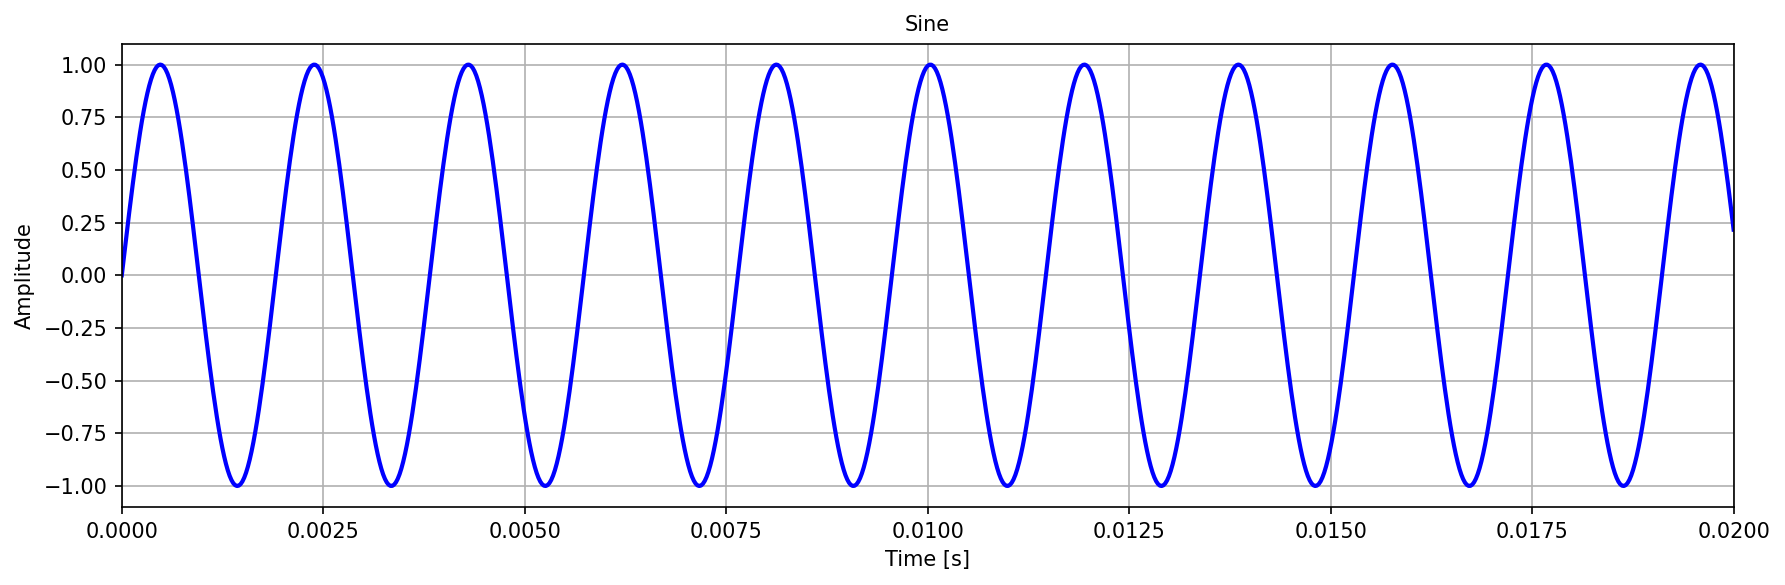

In [23]:
# Sine
f0 = 523.25 # C5

phi0 = 2*np.pi*f0*t
y_basic_sine = np.sin(phi0);

fig = plt.figure(figsize=(12,4))
plt.plot(t,y_basic_sine,'b-')
plt.xlim([0,0.02])
plt.title('Sine')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.grid(True)
plt.savefig('./figs/single_sine.png', bbox_inches='tight', dpi=300)
plt.show()

In [24]:
write("data/y_basic_sine.wav", fs, y_basic_sine.astype(np.float32))
ipd.Audio('data/y_basic_sine.wav', rate = fs) # 

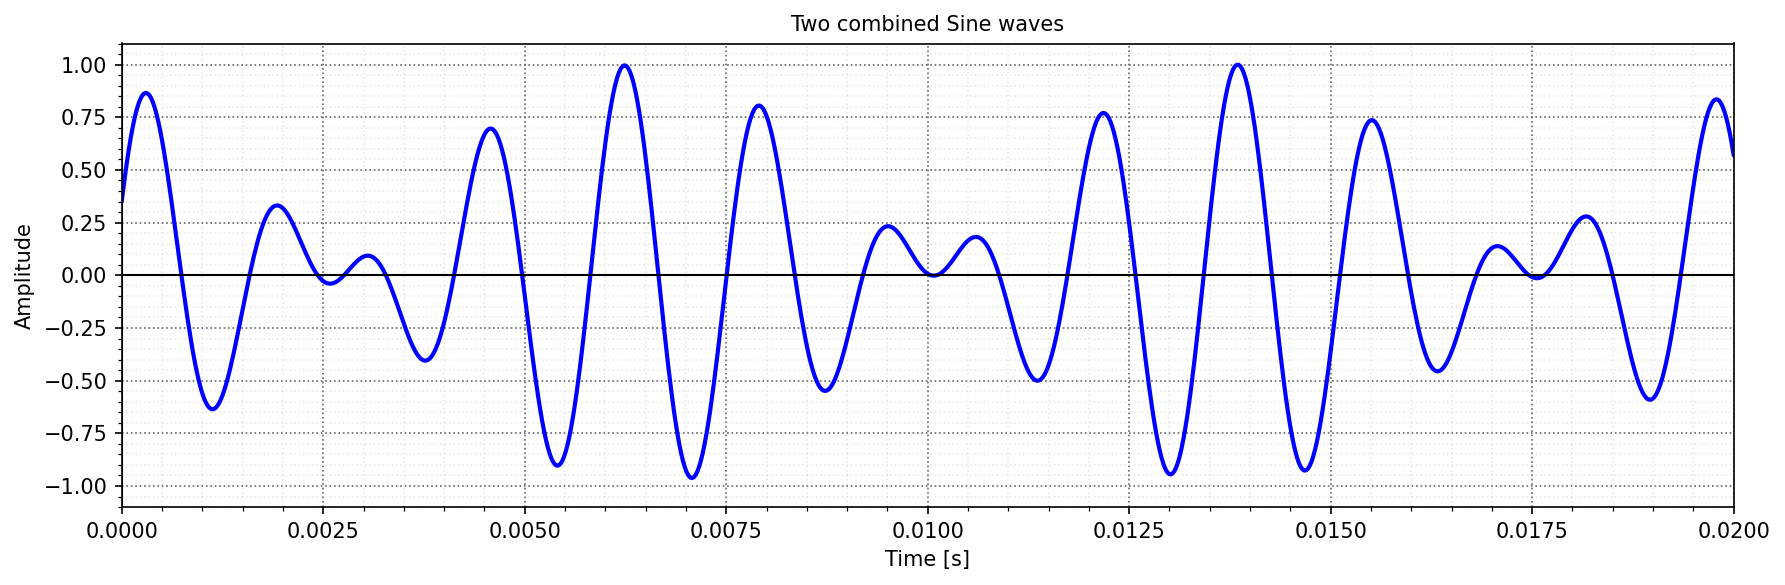

In [25]:
# multisine
f1 = 659.25 # E5
offset = np.pi/4
phi1 = 2*np.pi*f1*t + offset

y_basic_sine1 = y_basic_sine + np.sin(phi1);
y_basic_sine1 = y_basic_sine1/np.max(y_basic_sine1); # normalize

fig = plt.figure(figsize=(12,4))
plt.plot(t,y_basic_sine1,'b-')
plt.xlim([0,0.02])
plt.title('Multi-Sine')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
bm.nicegrid()
plt.title('Two combined Sine waves')
plt.savefig('./figs/multi_sine.png', bbox_inches='tight', dpi=300)
plt.show()

write("data/y_basic_sine1.wav", fs, y_basic_sine1.astype(np.float32))
ipd.Audio('data/y_basic_sine1.wav', rate=fs) # 

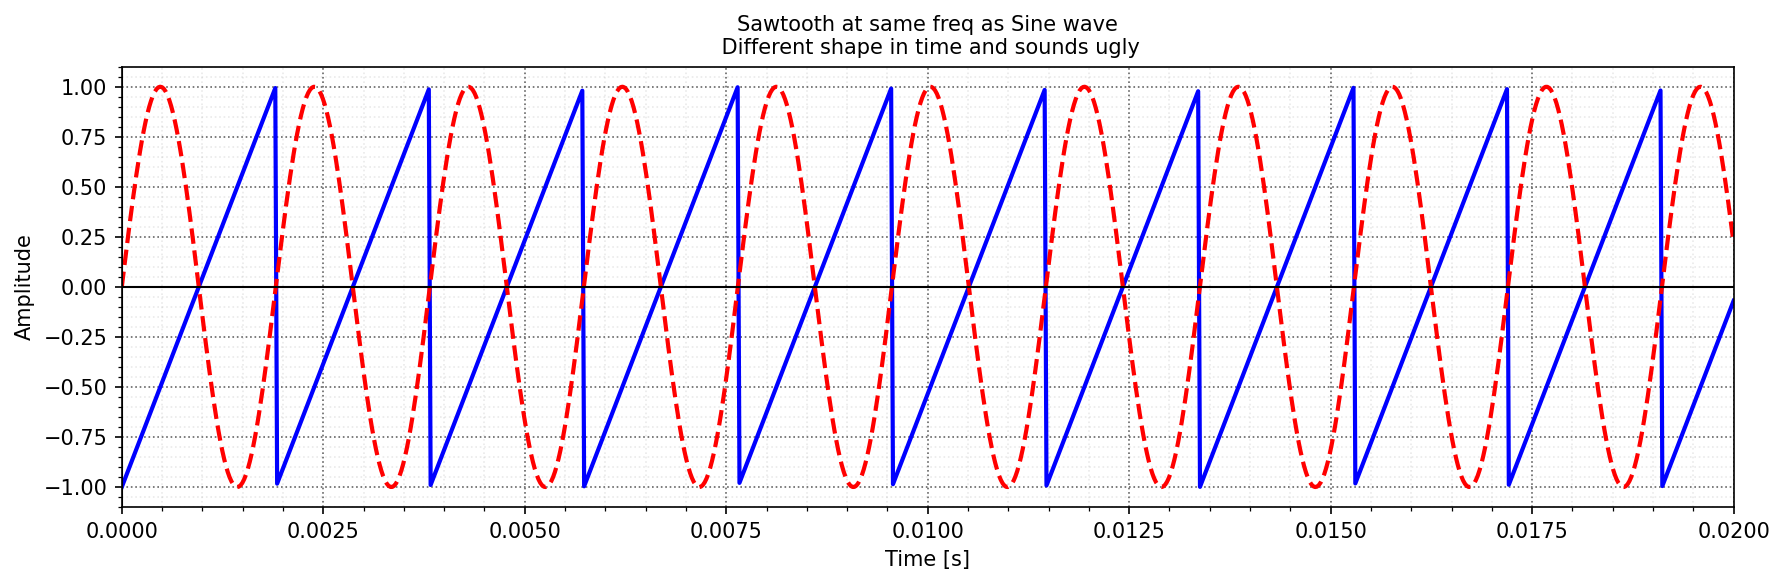

In [6]:
# Sawtooth
y_sawtooth = sp.sawtooth(phi0);

fig = plt.figure(figsize=(12,4))
plt.plot(t,y_sawtooth,'b-')
plt.plot(t,y_basic_sine,'r--')
plt.xlim([0,0.02])
plt.title('Sawtooth')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
bm.nicegrid()
plt.title('Sawtooth at same freq as Sine wave\n Different shape in time and sounds ugly')
plt.savefig('./figs/sawtooth.png', bbox_inches='tight', dpi=300)
plt.show()

write("data/y_sawtooth.wav", fs, y_sawtooth.astype(np.float32))
ipd.Audio('data/y_sawtooth.wav', rate=fs) # 

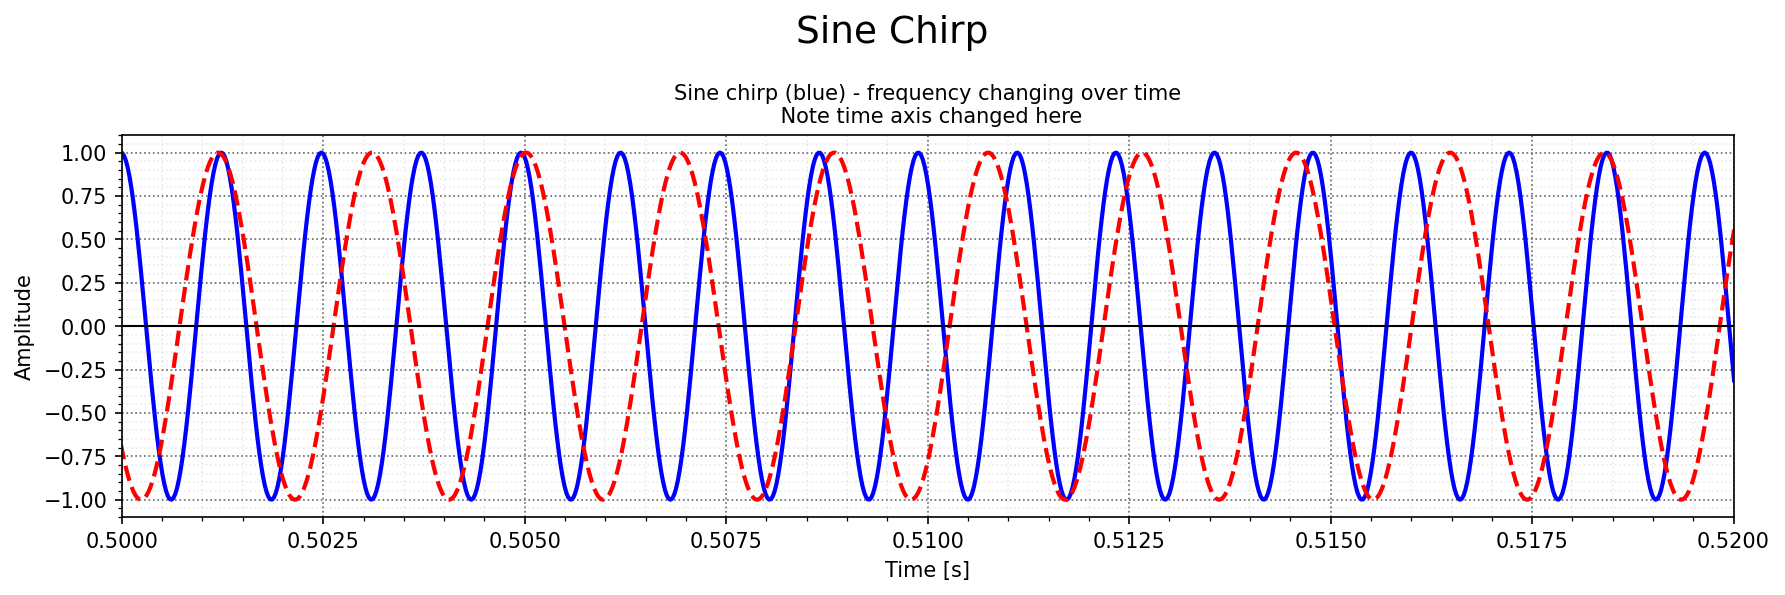

In [18]:
tf_long = 2
t_long = np.linspace(0,tf_long,int(tf_long*fs)) # time signal for plotting
beta = (5e3 - f0) / tf_long**2

phi2_long = 2*np.pi*(f0*t_long + beta*t_long**3/3)
y_sine_chirp = np.sin(phi2_long)

fig = plt.figure(figsize=(12,4))
plt.plot(t_long,y_sine_chirp,'b-')
plt.plot(t,y_basic_sine,'r--')
plt.xlim([tf/2,tf/2+0.02])
plt.suptitle('Sine Chirp')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
bm.nicegrid()
plt.title('Sine chirp (blue) - frequency changing over time\n Note time axis changed here')
plt.savefig('./figs/sine_chirp.png', bbox_inches='tight', dpi=300)
plt.show()

write("data/y_sine_chirp.wav", fs, y_sine_chirp.astype(np.float32))
ipd.Audio('data/y_sine_chirp.wav', rate=fs) # 

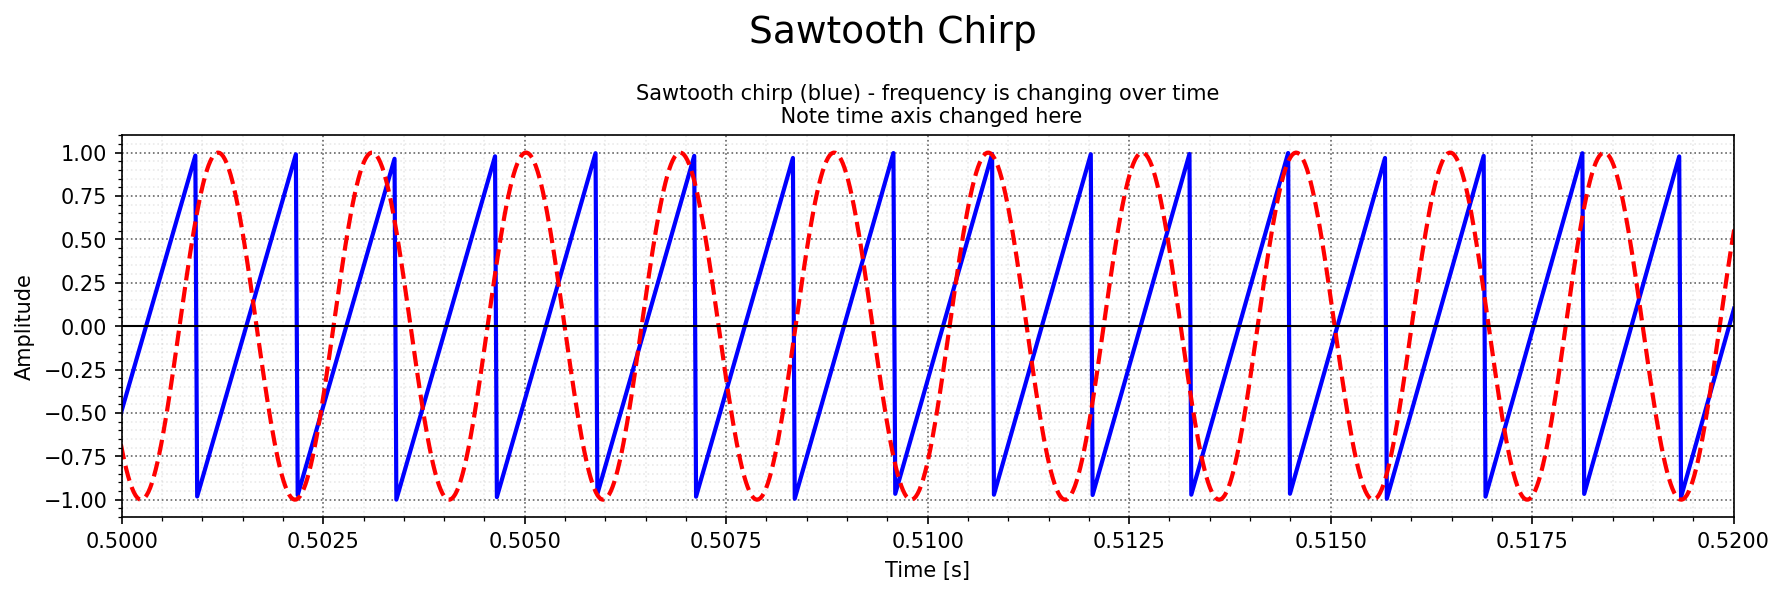

In [20]:
y_sawtooth_chirp = sp.sawtooth(phi2_long);

fig = plt.figure(figsize=(12,4))
plt.plot(t_long,y_sawtooth_chirp,'b-')
plt.plot(t,y_basic_sine,'r--')
plt.xlim([tf/2,tf/2+0.02])
plt.suptitle('Sawtooth Chirp')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
bm.nicegrid()
plt.title('Sawtooth chirp (blue) - frequency is changing over time\n Note time axis changed here')
plt.savefig('./figs/sawtooth_chirp.png', bbox_inches='tight', dpi=300)
plt.show()

write("data/y_sawtooth_chirp.wav", fs, y_sawtooth_chirp.astype(np.float32))
ipd.Audio('data/y_sawtooth_chirp.wav', rate=fs) # 

## Frequency Domain Signal Visualization 

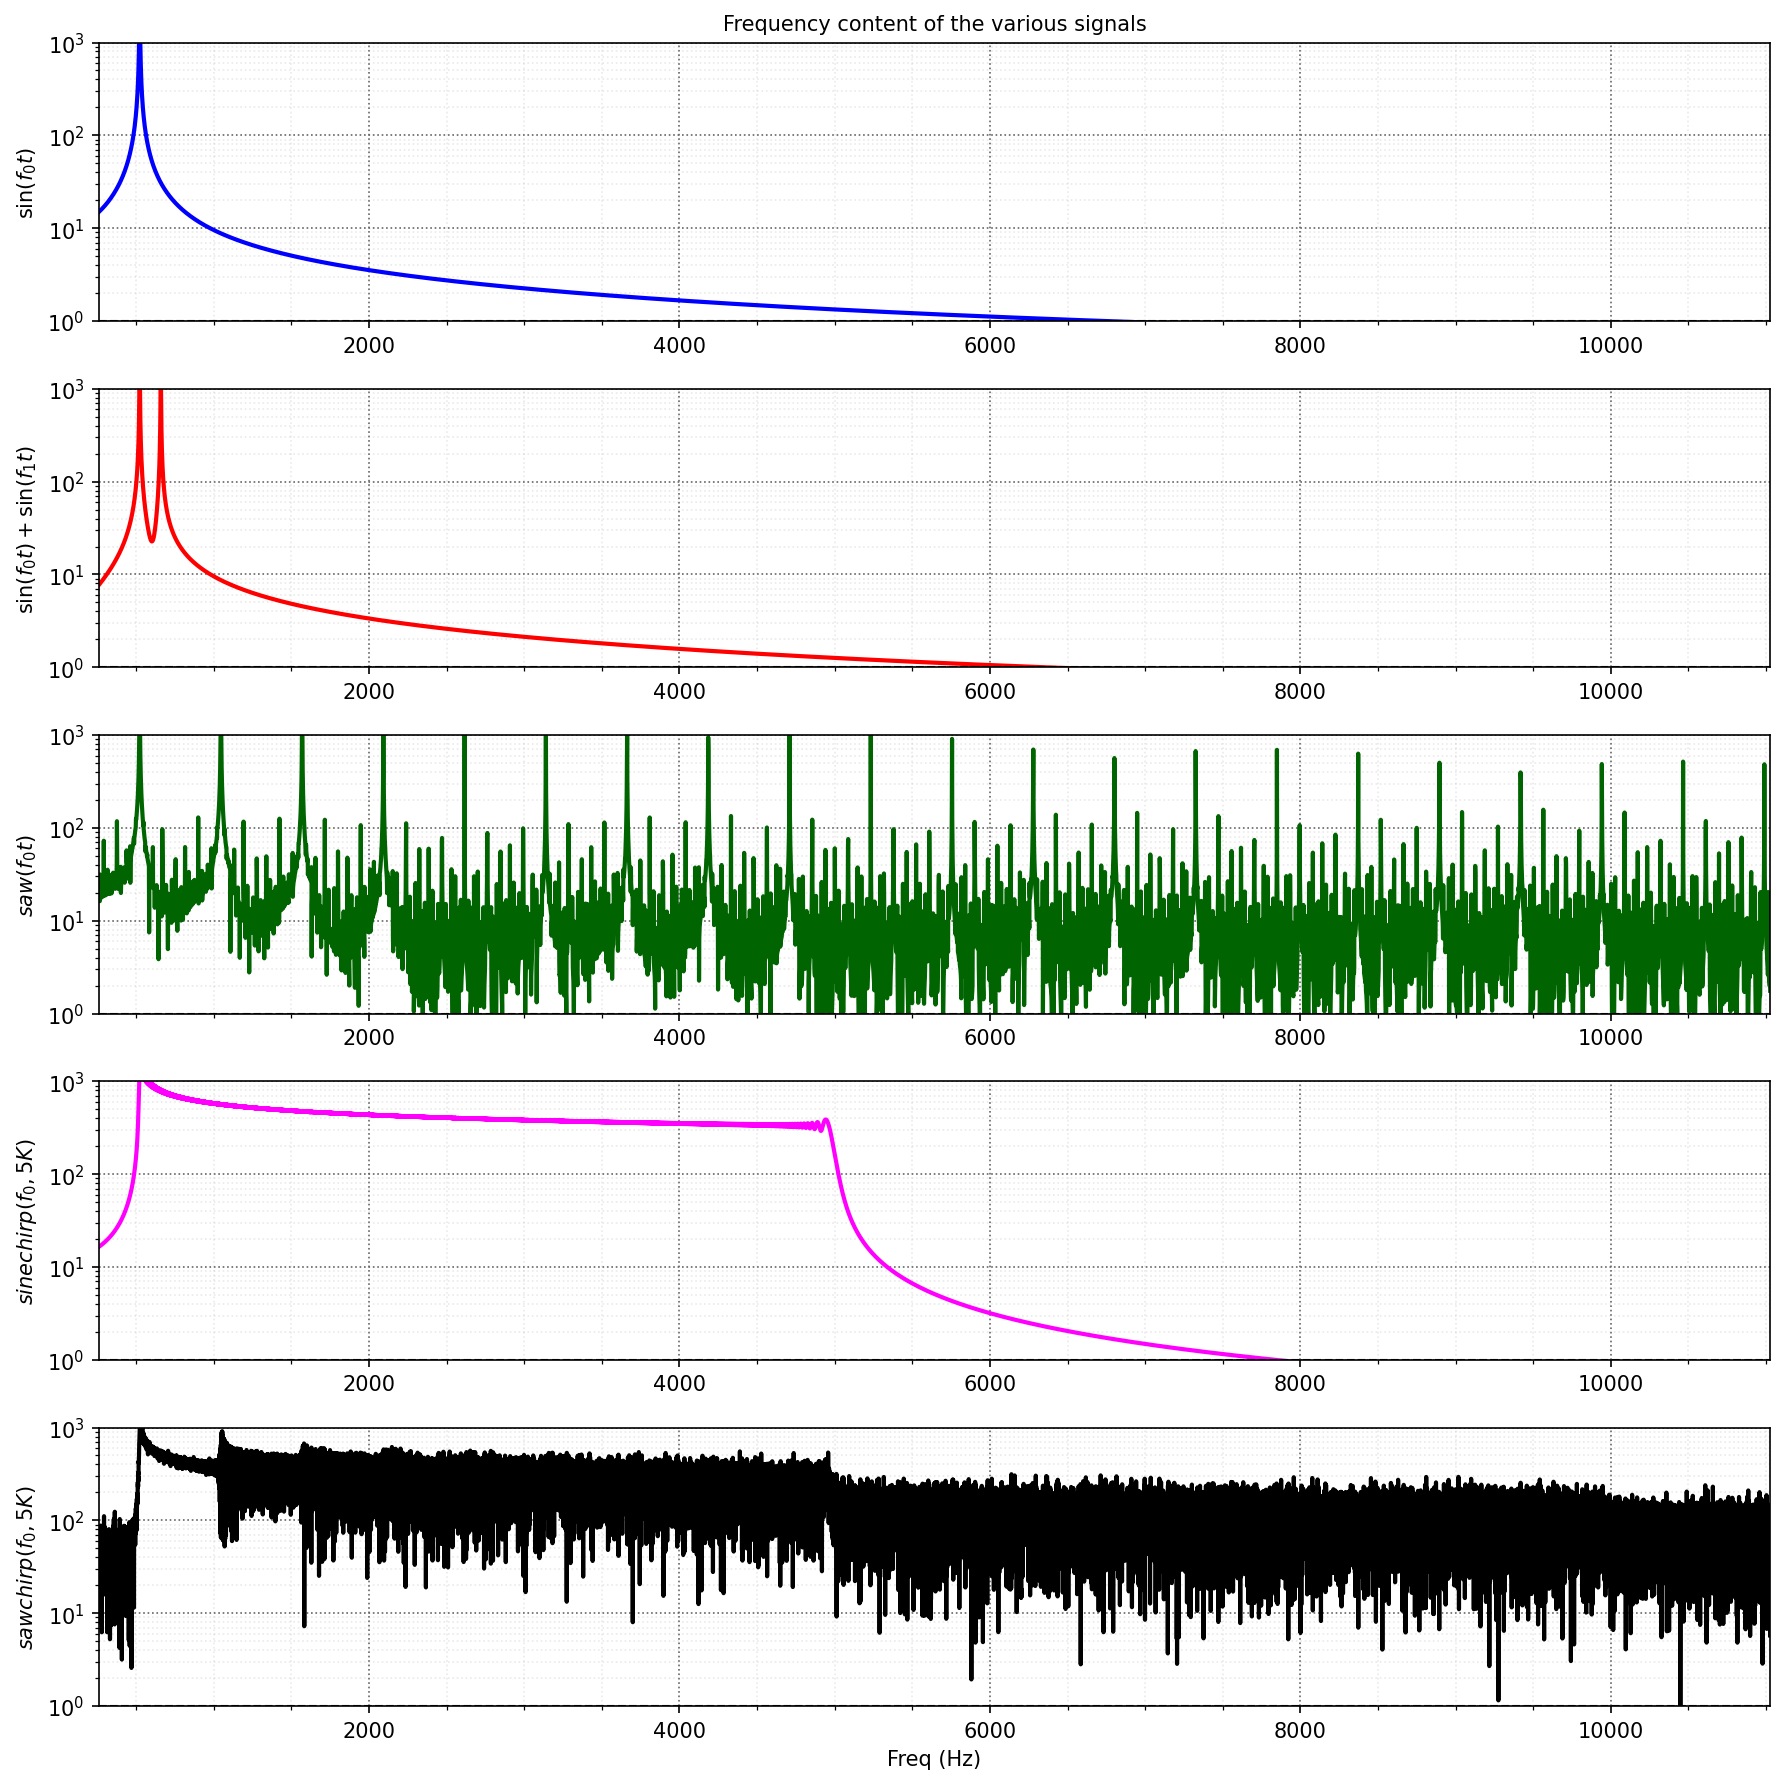

In [27]:
fig = plt.figure(figsize=(12,12))

ax1 = plt.subplot(511)
X = fft(y_basic_sine[:NFFT])

ax1.semilogy(freq, np.abs(X), colors[0])
ax1.set_ylabel('$\sin(f_0 t)$')
ax1.set_title('Frequency content of the various signals')
bm.nicegrid(ax1)
ax1.set_ylim(1, 1000)
ax1.set_xlim(f0/2, fs/4)

ax2 = plt.subplot(512,sharex=ax1,sharey=ax1)
X = fft(y_basic_sine1[:NFFT])
ax2.semilogy(freq, np.abs(X), colors[1])
ax2.set_ylabel('$\sin(f_0 t)+\sin(f_1 t)$')
bm.nicegrid(ax2)

ax3 = plt.subplot(513,sharex=ax1,sharey=ax1)
X = fft(y_sawtooth[:NFFT])
ax3.semilogy(freq, np.abs(X), colors[2])
ax3.set_ylabel('$saw(f_0 t)$')
bm.nicegrid(ax3)

NC = len(y_sine_chirp)              # 88200, the full 2 s
freq_c = fs*np.arange(0,1,1/NC)
X = fft(y_sine_chirp)               # panel 4

ax22 = plt.subplot(514,sharex=ax1,sharey=ax1)
ax22.semilogy(freq_c, np.abs(X), colors[3])
ax22.set_ylabel('$sinechirp(f_0,5K)$')
bm.nicegrid(ax22)

ax4 = plt.subplot(515,sharex=ax1,sharey=ax1)
X = fft(y_sawtooth_chirp)           # panel 5
ax4.semilogy(freq_c, np.abs(X), colors[4])
ax4.set_ylabel('$sawchirp(f_0,5K)$')
bm.nicegrid(ax4)
ax4.set_xlabel('Freq (Hz)')
plt.show()
fig.savefig('./figs/FreqVisual_001.png', bbox_inches='tight', dpi=300)

## Frequency/Time Signal Visualization - Signal Variations

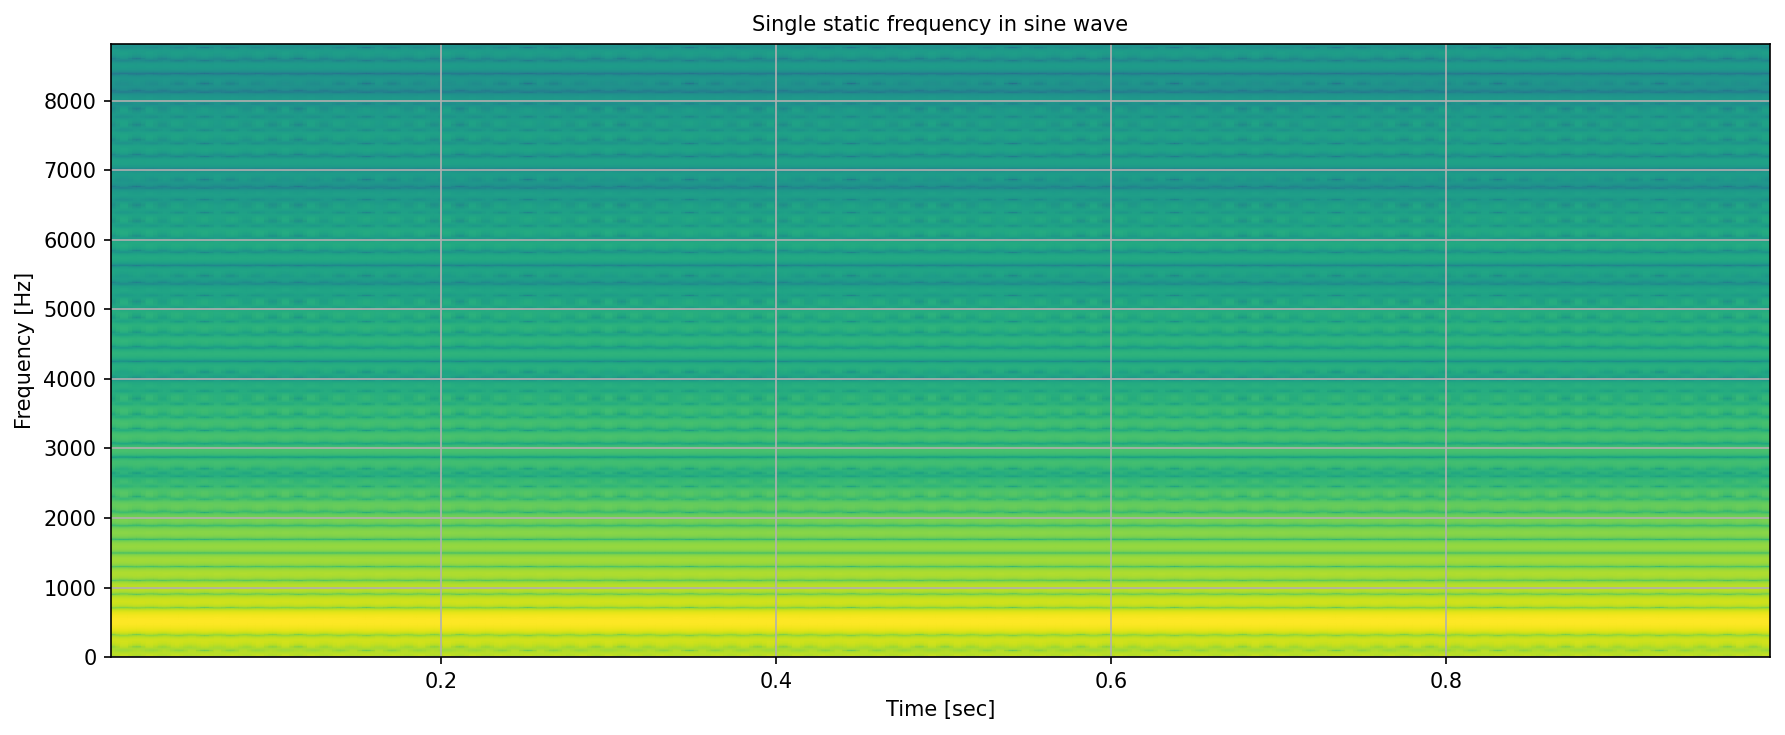

In [15]:
ff0, tt0, Sxx0 = sp.spectrogram(y_basic_sine, fs, detrend=False, nfft = NFFT)
ff01, tt01, Sxx01 = sp.spectrogram(y_basic_sine1, fs, detrend=False, nfft = NFFT)
ff2, tt2, Sxx2 = sp.spectrogram(y_sine_chirp, fs, detrend=False, nfft = NFFT)

fig = plt.figure(figsize=(12,5))
plt.pcolormesh(tt0, ff0, np.log10(Sxx0), shading='gouraud')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.title('Sine')
plt.ylim([0,fs/5])
plt.title('Single static frequency in sine wave')
plt.show()
fig.savefig('./figs/FreqVisual_002.png', bbox_inches='tight', dpi=300)

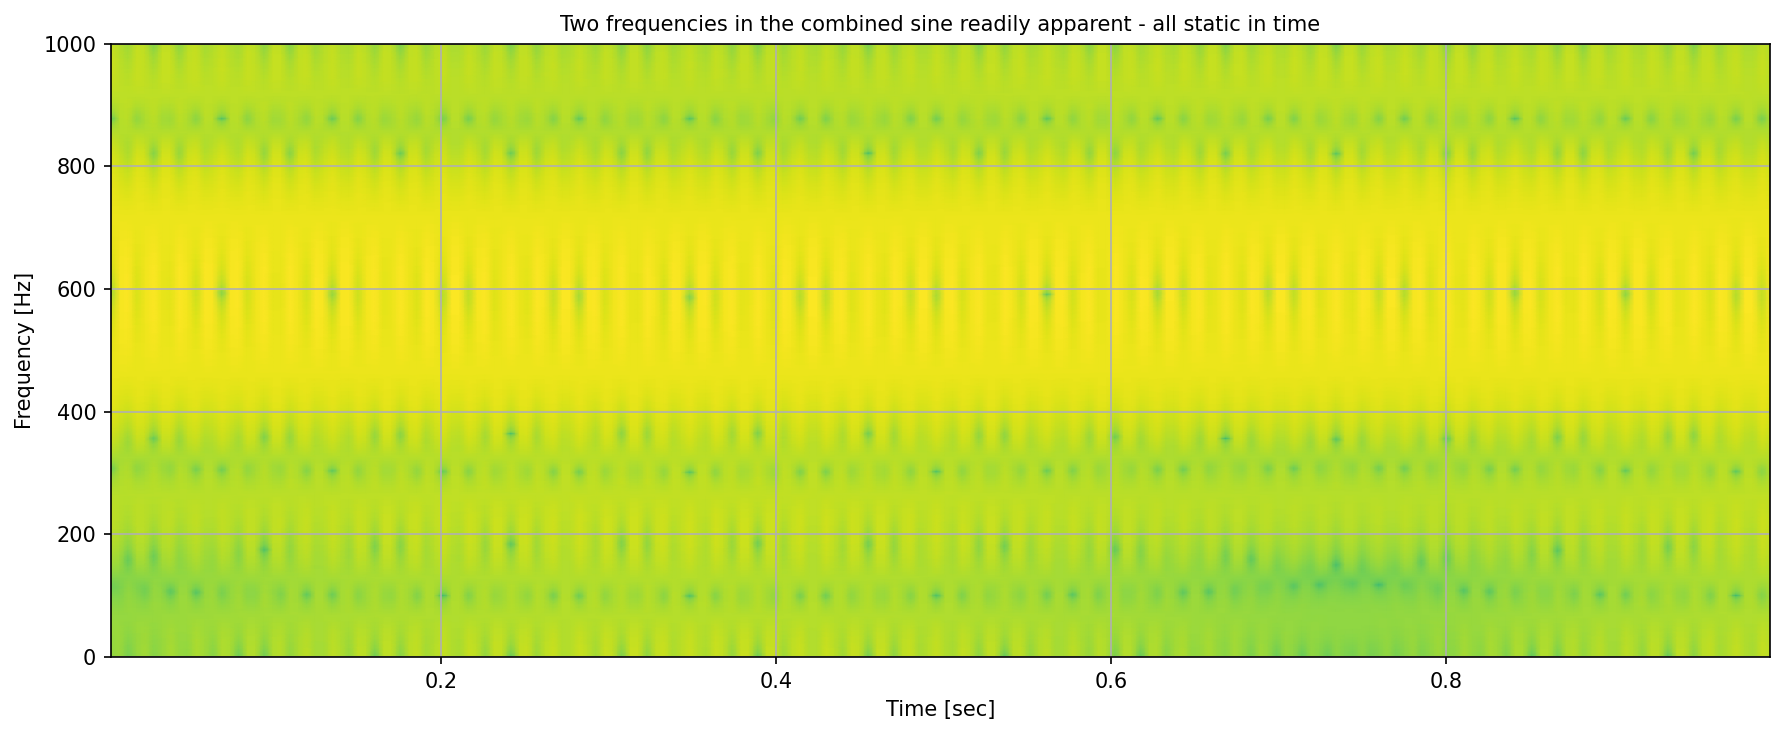

In [17]:
fig = plt.figure(figsize=(12,5))
plt.pcolormesh(tt01, ff01, np.log10(Sxx01), shading='gouraud')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.title('Multi Sine')
plt.ylim([0,1000])
plt.title('Two frequencies in the combined sine readily apparent - all static in time')
plt.show()
fig.savefig('./figs/FreqVisual_003.png', bbox_inches='tight', dpi=300)

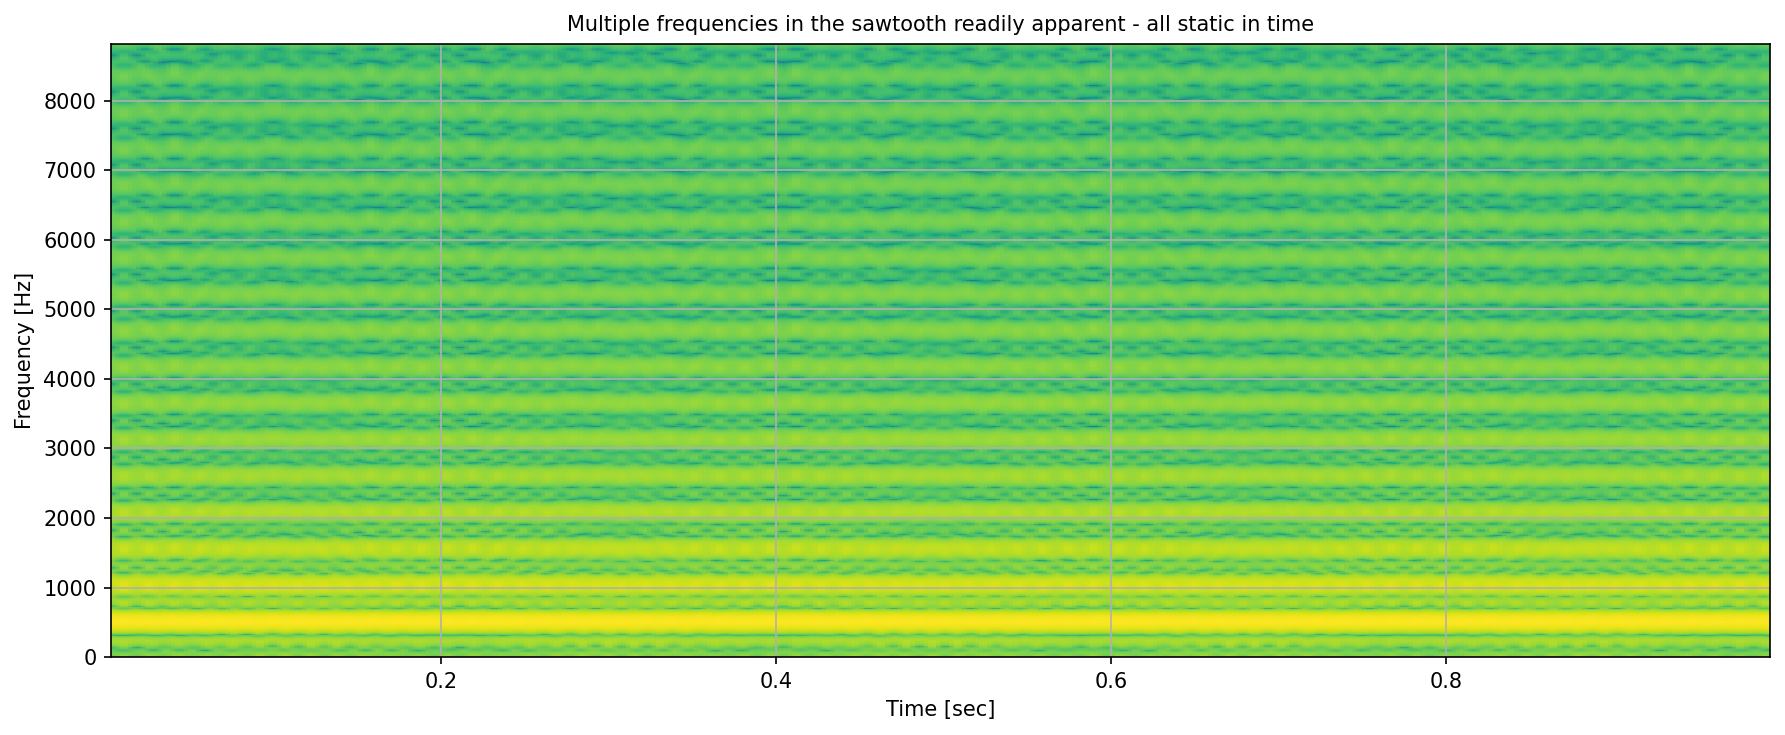

In [ ]:
ffs1, tts1, Sxxs1 = sp.spectrogram(y_sawtooth, fs, detrend=False, nfft = NFFT)

fig = plt.figure(figsize=(12,5))
plt.pcolormesh(tts1, ffs1, np.log10(Sxxs1), shading='gouraud')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.title('Sawtooth')
plt.ylim([0,fs/5])
plt.title('Multiple frequencies in the sawtooth readily apparent - all static in time')
plt.show()
fig.savefig('./figs/FreqVisual_004.png', bbox_inches='tight', dpi=300)

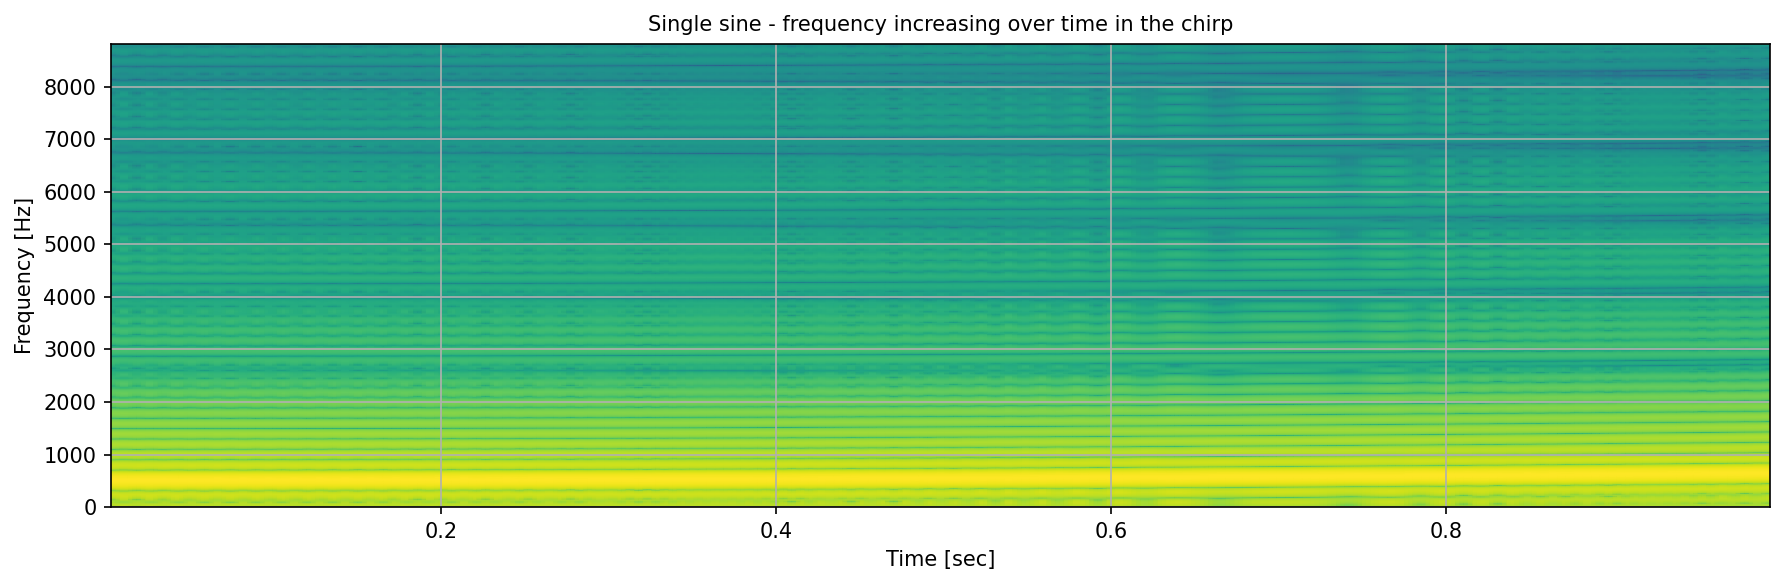

In [ ]:
fig = plt.figure(figsize=(12,4))
plt.pcolormesh(tt2, ff2, np.log10(Sxx2), shading='gouraud')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.title('Sine Chirp')
plt.ylim([0, fs/5])
plt.title('Single sine - frequency increasing over time in the chirp')
plt.show()
fig.savefig('./figs/FreqVisual_005.png', bbox_inches='tight', dpi=300)

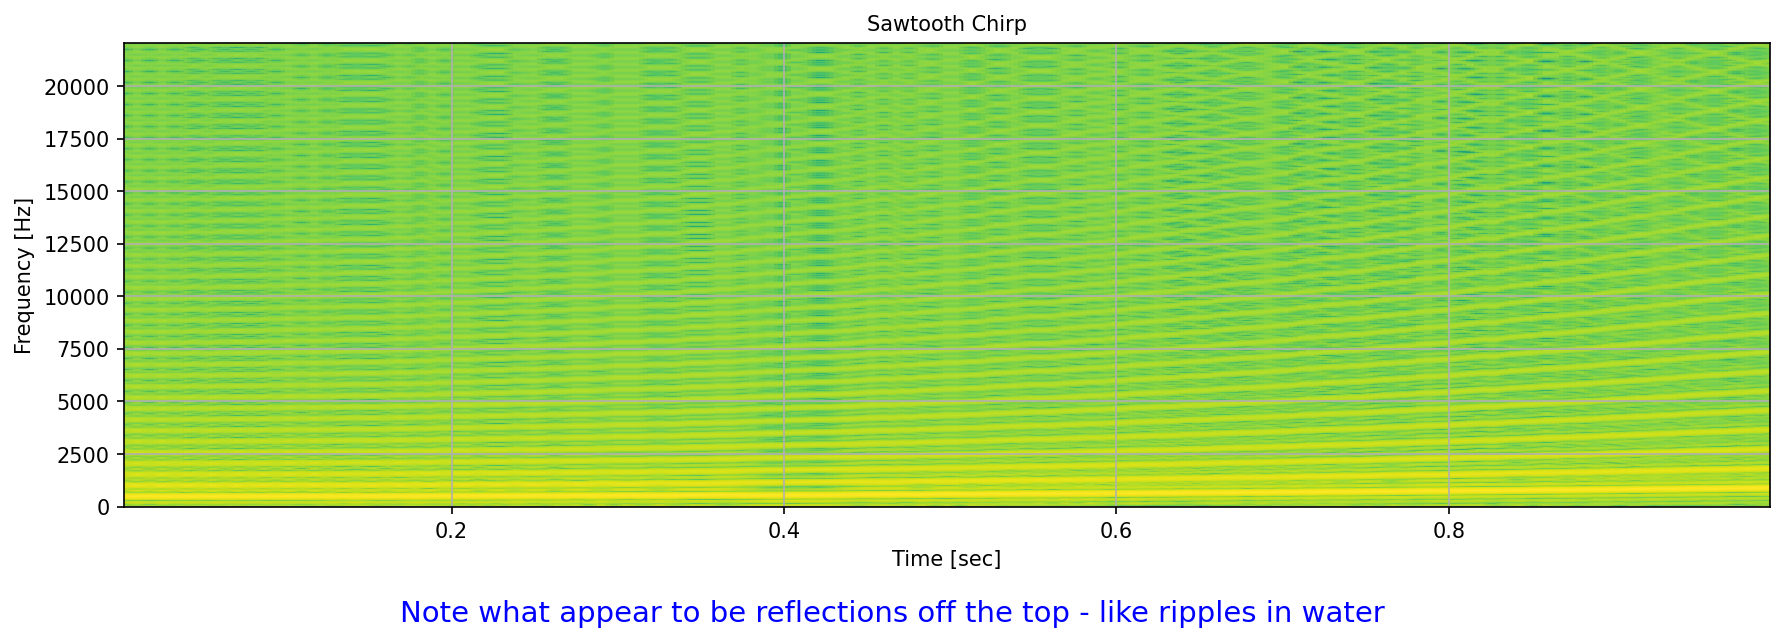

In [ ]:
ffs2, tts2, Sxxs2 = sp.spectrogram(y_sawtooth_chirp, fs, detrend=False, nfft = NFFT)

fig = plt.figure(figsize=(12,4))
plt.pcolormesh(tts2, ffs2, np.log10(Sxxs2), shading='gouraud')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.title('Sawtooth Chirp')
plt.ylim([0, fs/2])
plt.title('Note what appear to be reflections off the top - like ripples in water')
plt.show()
fig.savefig('./figs/FreqVisual_006.png', bbox_inches='tight', dpi=300)